# Fractional Brownian Motion
Fractional brownian motion is defined by the stochastic integral,

$
\begin{align}
Z^H_t = \frac{1}{C^H} \int_{-\infty}^{\infty} \left[ (t-s)^{H-\frac{1}{2}}_+ - (-s)^{H-\frac{1}{2}}_+ \right] dB_s
\end{align}
\tag{1}
$

where, </br>

$
\begin{align}
C^H = \Bigg\{ \int_{-\infty}^0  \left[ (t-s)^{H-\frac{1}{2}}_+ - (-s)^{H-\frac{1}{2}}_+ \right] ds + \frac{1}{2H} \Bigg\} ^{\frac{1}{2}}
\end{align}
\tag{2}
$

Then mean, variance, covariance are given by,

$
\begin{align}
&\text{E}[Z^H_t] = 0 \\
&\text{Var}[Z_t^H] = t^{2H} \\
&\text{Cov}[Z^H_t Z^H_s] = R^H(t,s) = \frac{1}{2}[t^{2H}+s^{2H}-(t-s)^{2H}],
\end{align}
\tag{3}
$

where $t > s$.

Let $\Delta Z^H_t$ denote an increment of fractional brownian noise, then the mean, variance and autocovariance separated in time by $n$ is given by,<br>

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z_t^H] = \Delta t^{2H} \\
&\rho^H_n = \frac{1}{2}[(n - 1)^{2H} + (n + 1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

Fractional brownian motion is stationary, so for $t > s$

$
\begin{align}
Z^H_{s+t} - Z^H_s \sim Z^H_s
\end{align}
\tag{5}
$

and self similar,

$
\begin{align}
Z^H_{at} \sim a^H Z_t
\end{align}
\tag{6}
$

It is easy to see that,

$
\begin{align}
&\text{Var}[Z_{at}^H] = a^{2H}t^{2H} = a^{2H}\text{Var}[Z_{t}^H]\\
&\text{Cov}[Z^H_{at} Z^H_{as}] = a^{2H}\frac{1}{2}[t^{2H}+s^{2H}-(t-s)^{2H}] = a^{2H}\text{Cov}[Z^H_{t} Z^H_{s}],
\end{align}
\tag{7}
$

Two methods are used to simulate fractional brownian motion. The Cholesky method is uses Cholesky decomposition to decompose the fractional brownian motion covariance matrix for a bivariate Gaussian distribution and the FFT method uses Fast-Fourier transforms in a similar matter. The FFT method is much faster but is inaccurate for values of $H$ near 1.

## Imports

In [2]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, bm
from lib.plots import comparison, curve, stack
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [3]:
Δt = 1.0
npts = 1024

def labels(H_vals):
    return [f"H={H}" for H in H_vals]

## Fractional Brownian Noise

Fractional brownian noise is generated from brownian noise. The Noise here is used as the input for</br>
the following simulations for comparison.

In [4]:
t, dB = bm.create_bm_noise_source(npts=npts + 1)

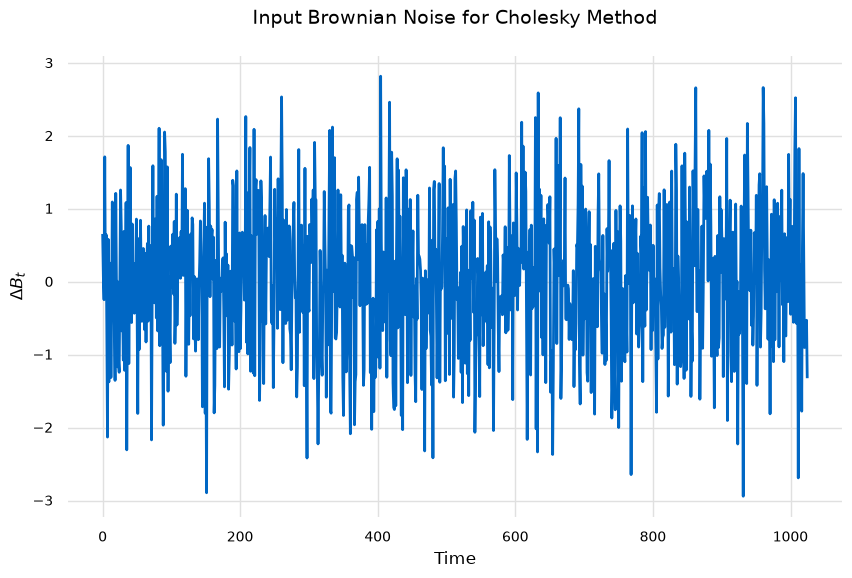

In [5]:
title = "Input Brownian Noise for Cholesky Method"
curve(dB, t, title=title, xlabel="Time", ylabel=r"$\Delta B_t$")

### Cholesky Fractional Brownian Noise
This noise is created using the Cholesky algorithm. Fractional brownian motion is created by summing fractional nrownian noise.

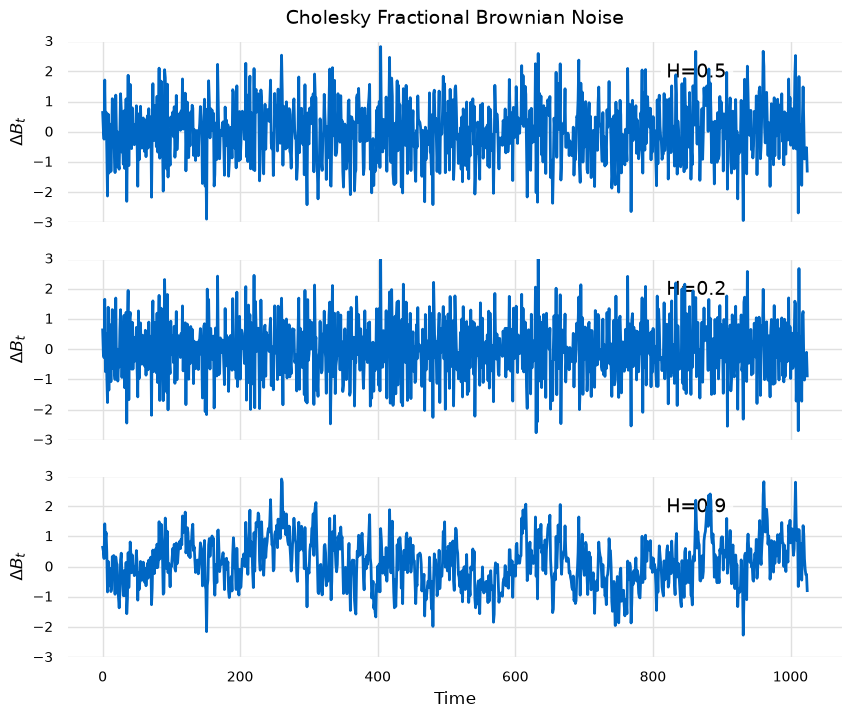

In [6]:
title = f"Cholesky Fractional Brownian Noise"
H_vals = [0.5, 0.2, 0.9]
params = [{"dB": dB, "npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_noise_cholesky_source(**kwargs)
_, scan = create_parameter_scan(source, *params)
stack(scan, ylim=[-3.0, 3.0], title=title, labels=labels(H_vals), figsize=(10, 8), xlabel="Time", ylabels=r"$\Delta B_t$")

### FFT Fractional Brownian Noise
This noise is created using the FFT algorothm. It generated from brownian noise. This noise is used the input for the following</br>
simulations for comparison. Fractional brownian motion is created by summing fractional brownian noise.

In [9]:
_, dB = bm.create_bm_noise_source(npts=2*npts)

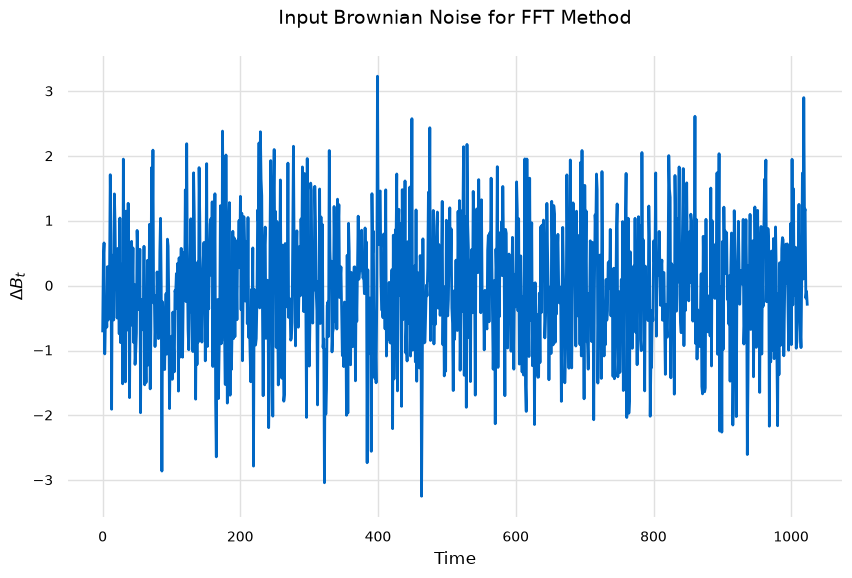

In [10]:
title = "Input Brownian Noise for FFT Method"
curve(dB, t, title=title, xlabel="Time", ylabel=r"$\Delta B_t$", npts=npts)

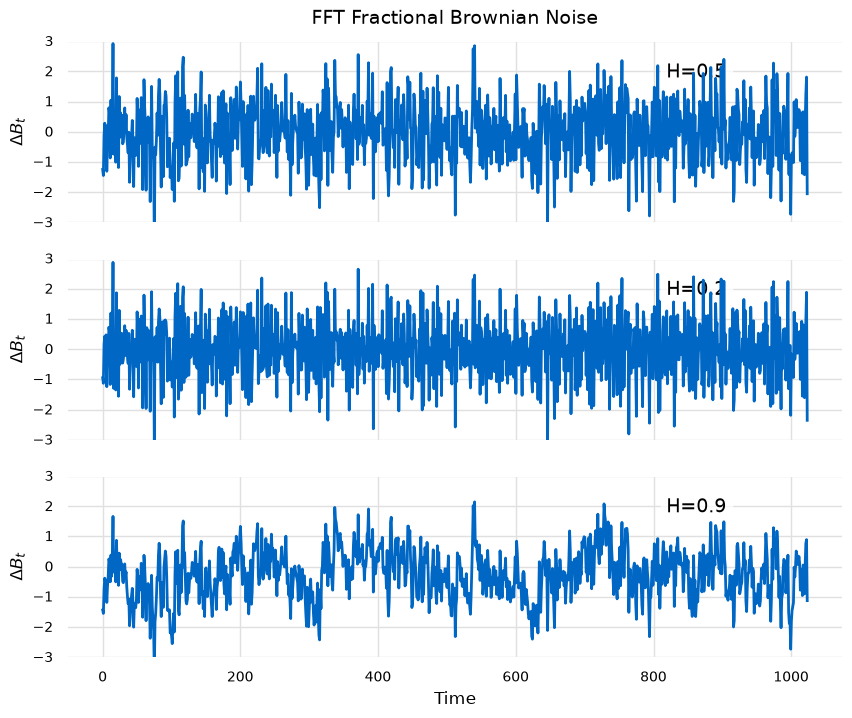

In [11]:
title = f"FFT Fractional Brownian Noise"
H_vals = [0.5, 0.2, 0.9]
params = [{"dB": dB, "npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_noise_fft_source(**kwargs)
_, scan = create_parameter_scan(source, *params)
stack(scan, ylim=[-3.0, 3.0], title=title, labels=labels(H_vals), figsize=(10, 8), xlabel="Time", ylabels=r"$\Delta B_t$")

## Cholesky Fractional Brownian Motion
Brownian motion created using the Cholesky method. This method is slower than the FFT method but performs well for all values of H.

In [12]:
H_vals = [0.55, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_cholesky_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

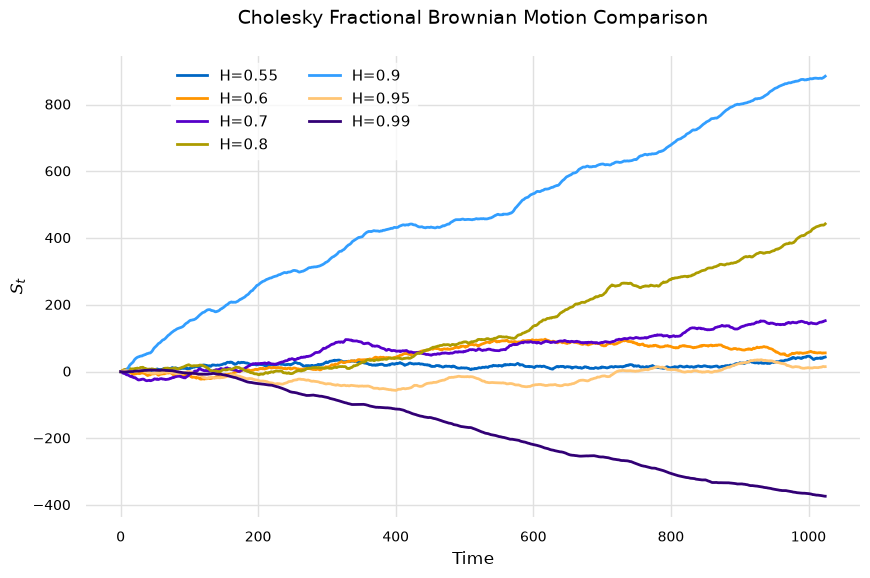

In [13]:
title = f"Cholesky Fractional Brownian Motion Comparison"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")

In [14]:
H_vals = [0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_cholesky_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

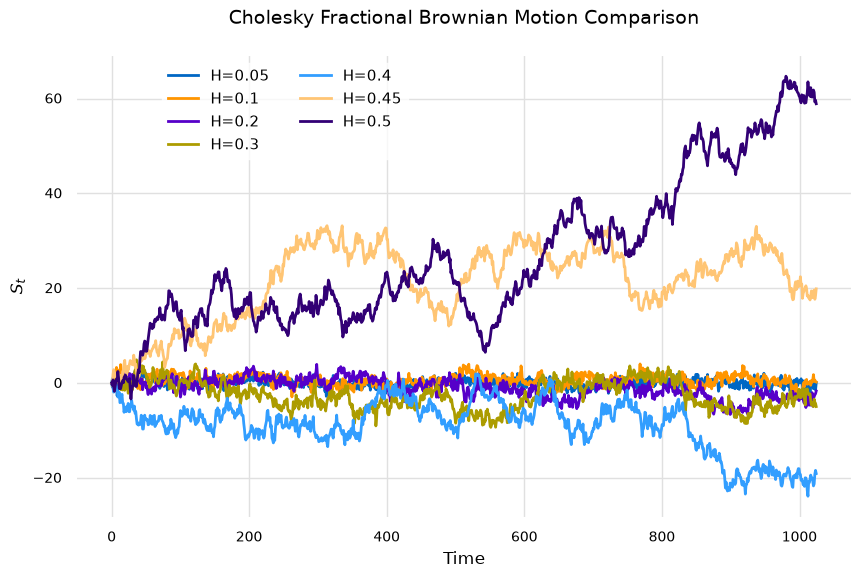

In [15]:
title = f"Cholesky Fractional Brownian Motion Comparison"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")

## FFT Brownian Motion
Fractional brownian motion created using the FFT method. This method is the fastest and will be used in analysis going forward but has problems for H larger than 0.9.

In [17]:
H_vals = [0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_fft_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

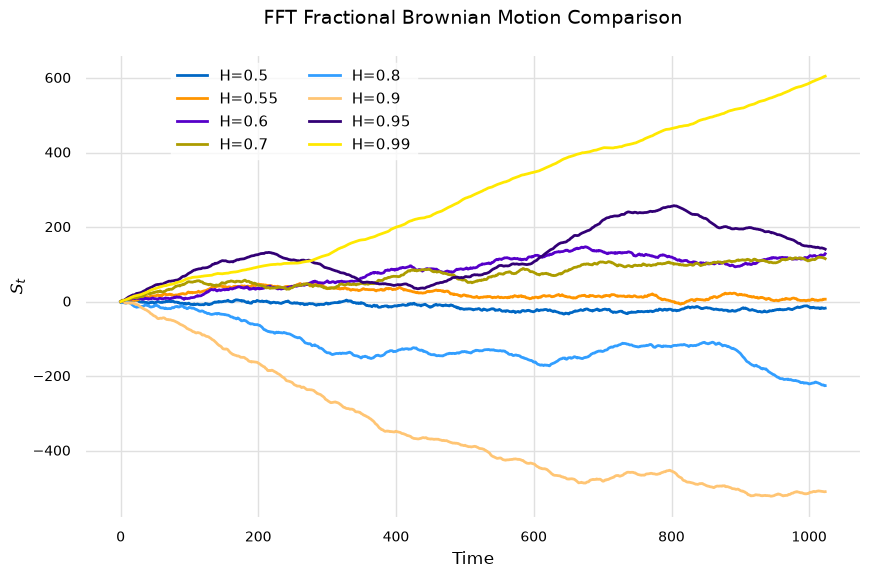

In [18]:
title = f"FFT Fractional Brownian Motion Comparison"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")

In [19]:
H_vals = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_fft_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

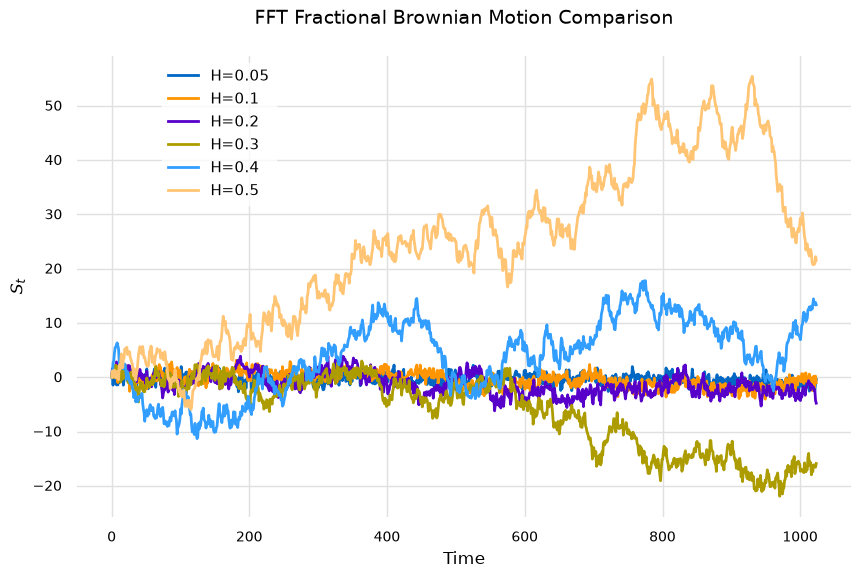

In [20]:
title = f"FFT Fractional Brownian Motion Comparison"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")

### FFT H Near 1

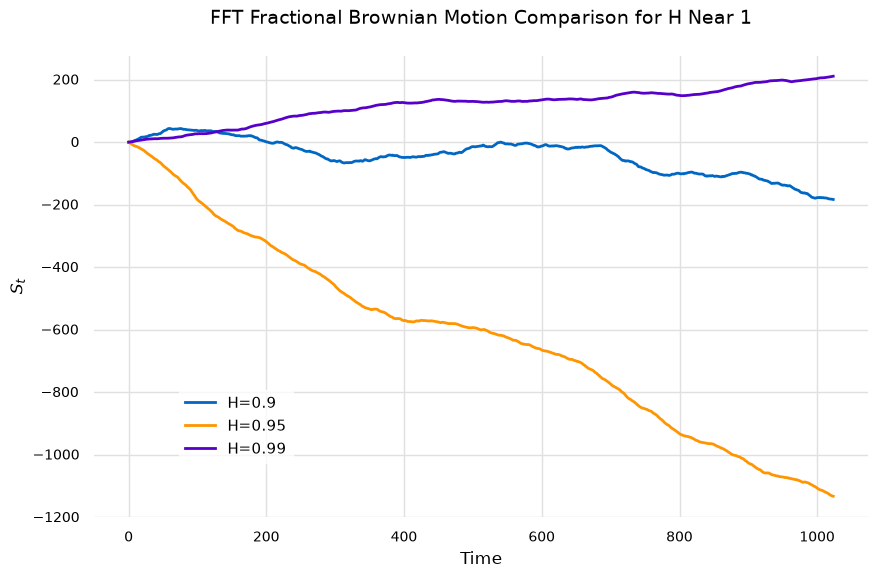

In [30]:
npts = 1024
H_vals = [0.9, 0.95, 0.99]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_fft_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

title = f"FFT Fractional Brownian Motion Comparison for H Near 1"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")

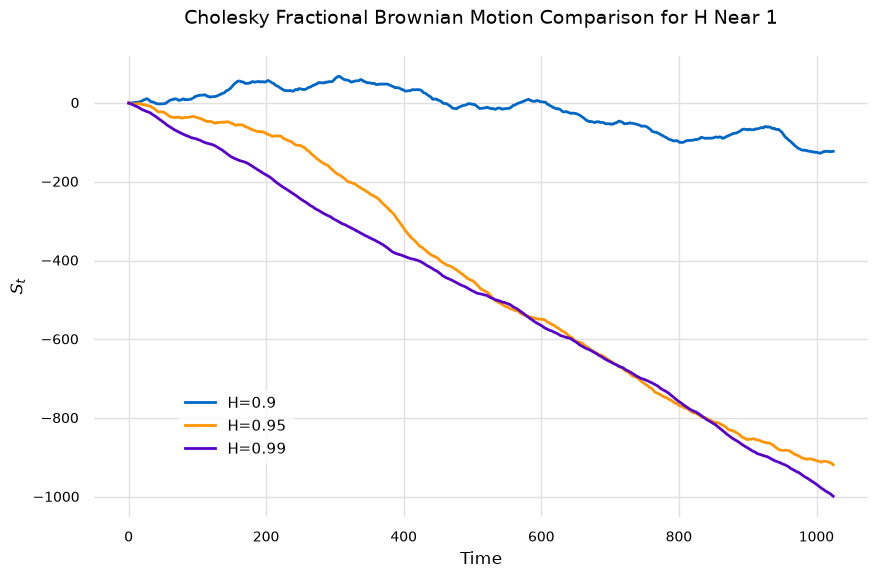

In [32]:
npts = 1024
H_vals = [0.9, 0.95, 0.99]
params = [{"npts": npts, "H": H} for H in H_vals]
source = lambda **kwargs : fbm.create_cholesky_source(**kwargs)
_, scan = create_parameter_scan(source, *params)

title = f"Cholesky Fractional Brownian Motion Comparison for H Near 1"
comparison(scan, title=title, labels=labels(H_vals), xlabel="Time", ylabel=r"$S_t$")